# Conditional Graph

In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List

In [13]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

In [14]:
def adder(state: AgentState) -> dict:
    """Adds number1 and number2."""
    return {
        "finalNumber": state["number1"] + state["number2"]
    }

def subtractor(state: AgentState) -> dict:
    """Subtracts number2 from number1."""
    return {
        "finalNumber": state["number1"] - state["number2"]
    }

def decide_next_node(state: AgentState) -> str:
    """Routes to correct node based on operation."""
    if state["operation"] == "+":
        return "adder_node"
    elif state["operation"] == "-":
        return "subtractor_node"
    else:
        raise ValueError("Invalid operation")

In [15]:
from langgraph.graph import StateGraph, START, END

# Initialize the graph with a shared state schema (AgentState)
# AgentState defines what data flows through all nodes
graph = StateGraph(AgentState)

# Add computation nodes
# "adder" node performs addition logic on the state
graph.add_node("adder", adder)

# "subtractor" node performs subtraction logic on the state
graph.add_node("subtractor", subtractor)

# Router node (passthrough)
# This node does NOT modify state
# It simply forwards the state to the routing function
graph.add_node("router", lambda state: state)

# Connect START → router
# This defines where execution begins
graph.add_edge(START, "router")

# Conditional routing from "router"
# decide_next_node(state) determines which node runs next
# It MUST return one of the keys: "adder_node" or "subtractor_node"
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "adder_node": "adder",         # if condition → go to adder
        "subtractor_node": "subtractor" # if condition → go to subtractor
    }
)

# Connect computation nodes → END
# This ensures graph execution stops after these nodes run
graph.add_edge("adder", END)
graph.add_edge("subtractor", END)

# Compile the graph into an executable app
# After this, you can call: app.invoke(state)
app = graph.compile()

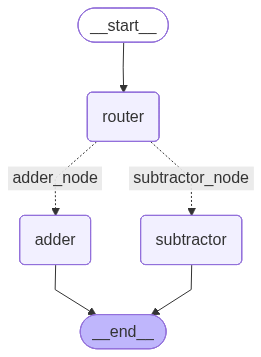

In [16]:
app

In [17]:
initial_state_1 = AgentState(number1=10, number2=5, operation="+")
result_1 = app.invoke(initial_state_1)

In [18]:
result_1

{'number1': 10, 'number2': 5, 'operation': '+', 'finalNumber': 15}